In [4]:
%load_ext autoreload
%autoreload 2

# from src.datasets import *
from src.datamodule import KH9CdDataModule
from main import read_rois_from_geopackage
from torchgeo.datasets.utils import BoundingBox
import torch
import matplotlib.pyplot as plt

import torchgeo

print(torchgeo.__version__)
print(torch.cuda.is_available())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
0.6.2
False


In [3]:
aoi_test_small = BoundingBox(119736.8306800332211424,120771.4748695194866741,487192.3094612115528435,487754.0150268116849475,0,1)


old_images_dir = '/home/moritz/masterarbeit/raster/KH-9/amsterdam/georeferenced/'
old_images_dir = '/home/moritz/masterarbeit/raster/KH-9/amsterdam/georeferenced/filtered'
new_images_dir = '/home/moritz/masterarbeit/raster/aerial_images_2023'
bag_buildings_dir = '/home/moritz/masterarbeit/vector/buildings'
experiment_name = 'nb_test'
experiment_dir = 'nb_test'
log_dir = '/home/moritz/masterarbeit/early_fusion/logs'
batch_size = 5
patch_size = 256
learning_rate = 0.0001
num_dataloader_workers = 8
val_split_pct = 0.2
test_split_pct = 0.1
# checkpoint_name = args.checkpoint_name
rois = read_rois_from_geopackage('/home/moritz/masterarbeit/vector/dataset_splits.gpkg')
aoi = None
task = 'ChangeStarFarSeg'


## Datamodule and augmentation testing

In [15]:
datamodule = KH9CdDataModule(
    old_images_dir=old_images_dir,
    new_images_dir=new_images_dir,
    bag_buildings_dir=bag_buildings_dir,
    batch_size=batch_size,
    num_workers=num_dataloader_workers,
    patch_size=patch_size,
    val_split_pct=val_split_pct,
    test_split_pct=test_split_pct,
    rois=rois,
    aoi=aoi,
)

datamodule.setup("fit")

Converting AerialImages res from (0.25, 0.25) to (0.8811479302070964, 0.881147930124137)
Converting BagBuildings res from (0.0001, 0.0001) to (0.8811479302070964, 0.881147930124137)


In [4]:
from torchgeo.datasets import unbind_samples

loader = datamodule.train_dataloader()
batch = next(iter(loader))


In [7]:
from src.task import CustomSemanticSegmentationTask

model = CustomSemanticSegmentationTask(
    model='unet',
    backbone='resnet50',
    weights=True,
    in_channels=4,
    num_classes=2,
    loss="ce",
    ignore_index=99,
    lr=1e-4,
    patience=10,
)
model.eval()


CustomSemanticSegmentationTask(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

AttributeError: 'NoneType' object has no attribute 'experiment'

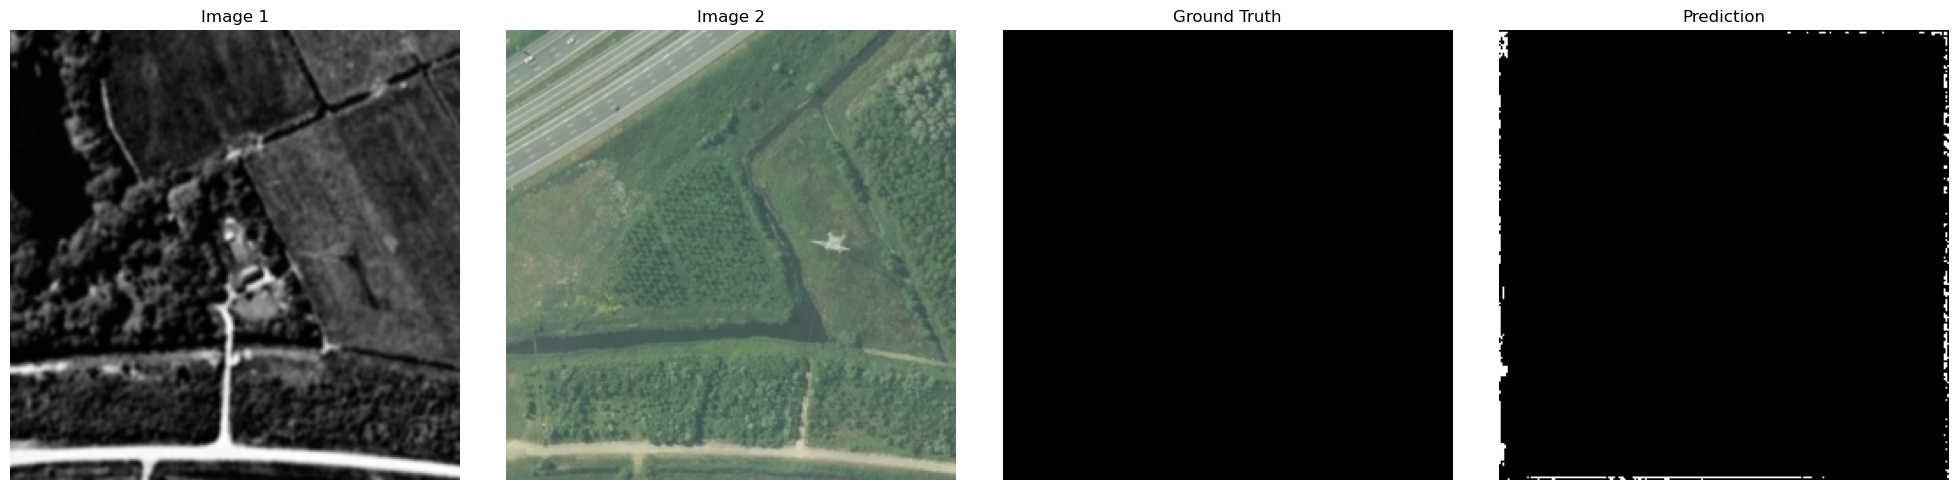

In [8]:
import copy

# Re-fetch fresh batch generator
dataloader = datamodule.train_dataloader()
iterator = iter(dataloader)

for idx in range(10):
    batch = next(iterator)
    batch_copy = copy.deepcopy(batch)  # Prevent mutation
    loss = model.training_step(batch_copy, idx)
    print(f"Step {idx} - Loss: {loss.item():.4f}")


## DualEncoderChangeDetectionTask Model Test
Test the custom dual-encoder model on a few batches from the datamodule.

In [21]:
%autoreload 2

from src.task import DualEncoderChangeDetectionTask


dual_encoder_model = DualEncoderChangeDetectionTask(
    encoder_old_name="resnet18",
    encoder_new_name="resnet18",
    num_classes=2,
    lr=1e-4,
    weights=True,
)
dual_encoder_model.eval()

[DualEncoder] Init: encoder_old_name=resnet18, encoder_new_name=resnet18, num_classes=2, lr=0.0001, weights=True, ignore_index=99


DualEncoderChangeDetectionTask(
  (encoder_old): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=

In [6]:
import copy

dataloader = datamodule.train_dataloader()
iterator = iter(dataloader)

for idx in range(5):
    batch = next(iterator)
    batch_copy = copy.deepcopy(batch)
    loss = dual_encoder_model.training_step(batch_copy, idx)
    print(f"DualEncoder Step {idx} - Loss: {loss.item():.4f}")

/home/moritz/miniforge3/envs/torchgeo/lib/python3.12/site-packages/lightning/pytorch/core/module.py:419: UserWarning: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`
  rank_zero_warn(
/home/moritz/miniforge3/envs/torchgeo/lib/python3.12/site-packages/torch/nn/functional.py:5082: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


DualEncoder Step 0 - Loss: 0.7580


/home/moritz/miniforge3/envs/torchgeo/lib/python3.12/site-packages/torch/nn/functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


DualEncoder Step 1 - Loss: 0.7845
DualEncoder Step 2 - Loss: 0.6614
DualEncoder Step 3 - Loss: 0.7228
DualEncoder Step 4 - Loss: 0.6677


In [22]:
# Overfit the dual encoder model on a single batch (overfitting test)
import copy

dataloader = datamodule.train_dataloader()
batch = next(iter(dataloader))
batch_copy = copy.deepcopy(batch)

# Set model to train mode
dual_encoder_model.train()
optimizer = torch.optim.Adam(dual_encoder_model.parameters(), lr=1e-4)

num_steps = 50
for step in range(num_steps):
    optimizer.zero_grad()
    loss = dual_encoder_model.training_step(batch_copy, step)
    loss.backward()
    optimizer.step()
    print(f"Overfit Step {step+1}/{num_steps} - Loss: {loss.item():.4f}")

[DualEncoder] training_step: x.shape=torch.Size([5, 4, 256, 256]), y.shape=torch.Size([5, 256, 256]), batch_idx=0
[DualEncoder] Forward: x.shape=torch.Size([5, 4, 256, 256])
[DualEncoder] old_img.shape=torch.Size([5, 1, 256, 256]), new_img.shape=torch.Size([5, 3, 256, 256])


/home/moritz/miniforge3/envs/torchgeo/lib/python3.12/site-packages/torch/nn/functional.py:5082: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/home/moritz/miniforge3/envs/torchgeo/lib/python3.12/site-packages/torch/nn/functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


[DualEncoder] old_feat.shape=torch.Size([5, 512, 1, 1]), new_feat.shape=torch.Size([5, 512, 1, 1])
[DualEncoder] old_feat (after squeeze/unsqueeze): torch.Size([5, 512, 1, 1]), new_feat: torch.Size([5, 512, 1, 1])
[DualEncoder] fused.shape=torch.Size([5, 1024, 1, 1])
[DualEncoder] fused after fuse_conv: torch.Size([5, 256, 1, 1])
[DualEncoder] fused_up.shape=torch.Size([5, 256, 256, 256])
[DualEncoder] decoder out.shape=torch.Size([5, 2, 256, 256]), min=-0.17106236517429352, max=0.08041176199913025
[DualEncoder] logits.shape=torch.Size([5, 2, 256, 256]), logits.min=-0.17106236517429352, logits.max=0.08041176199913025
[DualEncoder] y unique: tensor([0, 1])
[DualEncoder] loss=0.7677443623542786


/home/moritz/miniforge3/envs/torchgeo/lib/python3.12/site-packages/lightning/pytorch/core/module.py:419: UserWarning: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`
  rank_zero_warn(


Overfit Step 1/50 - Loss: 0.7677
[DualEncoder] training_step: x.shape=torch.Size([5, 4, 256, 256]), y.shape=torch.Size([5, 1, 256, 256]), batch_idx=1
[DualEncoder] Forward: x.shape=torch.Size([5, 4, 256, 256])
[DualEncoder] old_img.shape=torch.Size([5, 1, 256, 256]), new_img.shape=torch.Size([5, 3, 256, 256])
[DualEncoder] old_feat.shape=torch.Size([5, 512, 1, 1]), new_feat.shape=torch.Size([5, 512, 1, 1])
[DualEncoder] old_feat (after squeeze/unsqueeze): torch.Size([5, 512, 1, 1]), new_feat: torch.Size([5, 512, 1, 1])
[DualEncoder] fused.shape=torch.Size([5, 1024, 1, 1])
[DualEncoder] fused after fuse_conv: torch.Size([5, 256, 1, 1])
[DualEncoder] fused_up.shape=torch.Size([5, 256, 256, 256])
[DualEncoder] decoder out.shape=torch.Size([5, 2, 256, 256]), min=-0.15946978330612183, max=0.2486807405948639
[DualEncoder] logits.shape=torch.Size([5, 2, 256, 256]), logits.min=-0.15946978330612183, logits.max=0.2486807405948639
[DualEncoder] y unique: tensor([0, 1])
[DualEncoder] loss=0.549333

KeyboardInterrupt: 

[DualEncoder] Forward: x.shape=torch.Size([5, 4, 256, 256])
[DualEncoder] old_img.shape=torch.Size([5, 1, 256, 256]), new_img.shape=torch.Size([5, 3, 256, 256])
[DualEncoder] old_feat.shape=torch.Size([5, 512, 1, 1]), new_feat.shape=torch.Size([5, 512, 1, 1])
[DualEncoder] old_feat (after squeeze/unsqueeze): torch.Size([5, 512, 1, 1]), new_feat: torch.Size([5, 512, 1, 1])
[DualEncoder] fused.shape=torch.Size([5, 1024, 1, 1])
[DualEncoder] fused after fuse_conv: torch.Size([5, 256, 1, 1])
[DualEncoder] fused_up.shape=torch.Size([5, 256, 256, 256])
[DualEncoder] decoder out.shape=torch.Size([5, 2, 256, 256]), min=-4.005502700805664, max=4.129953384399414


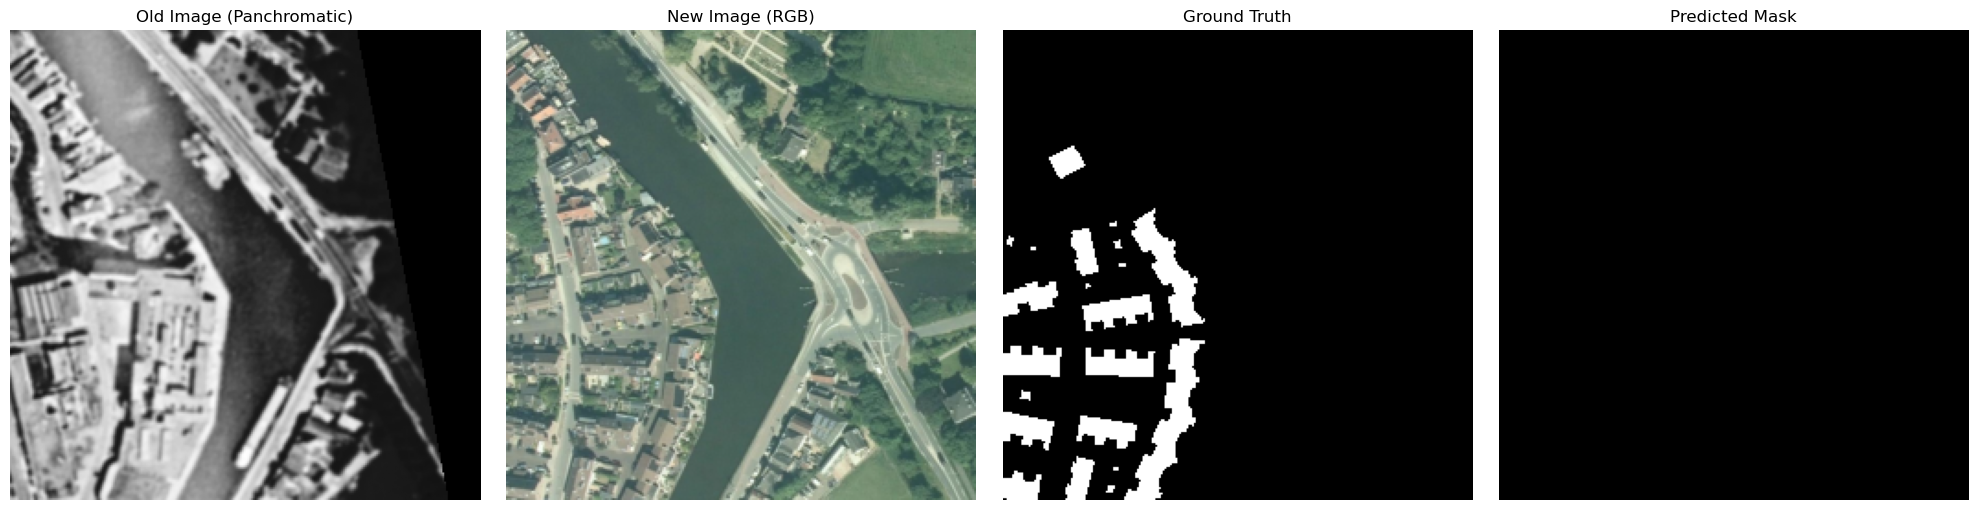

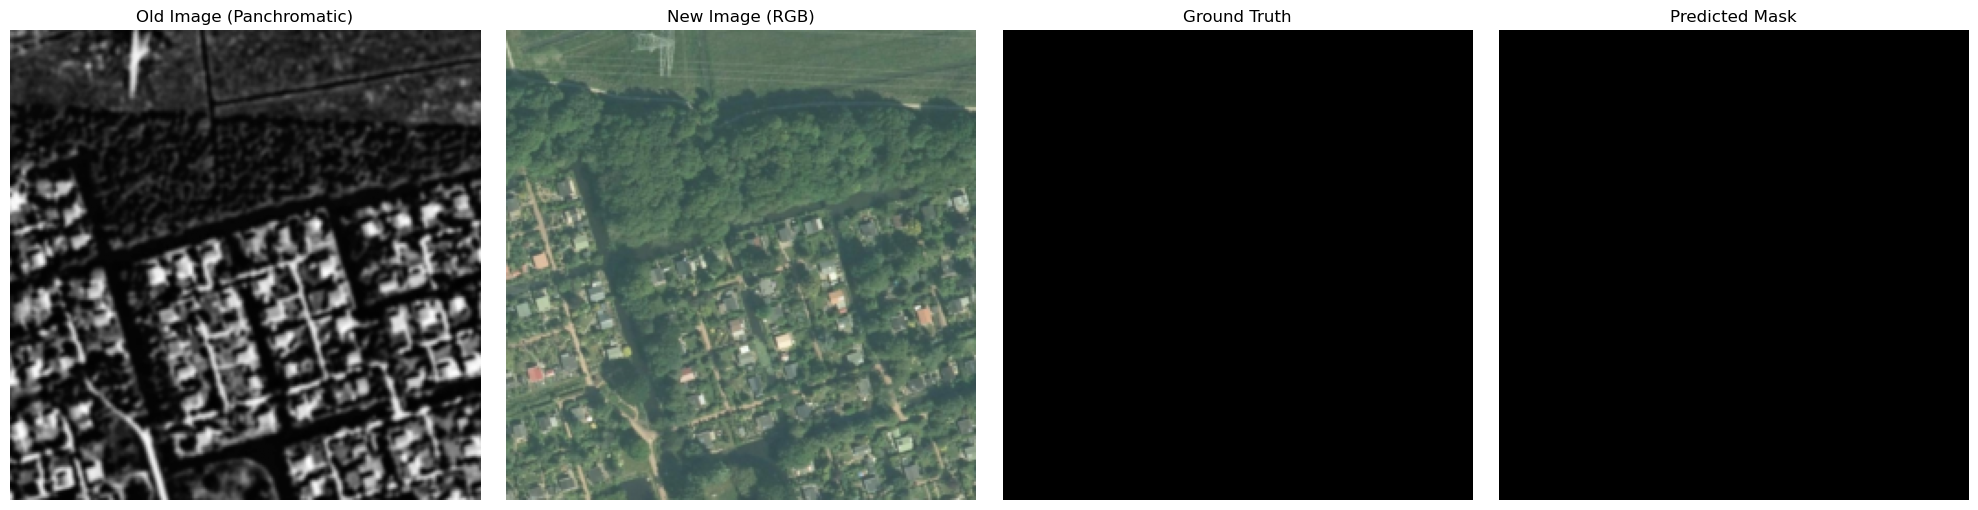

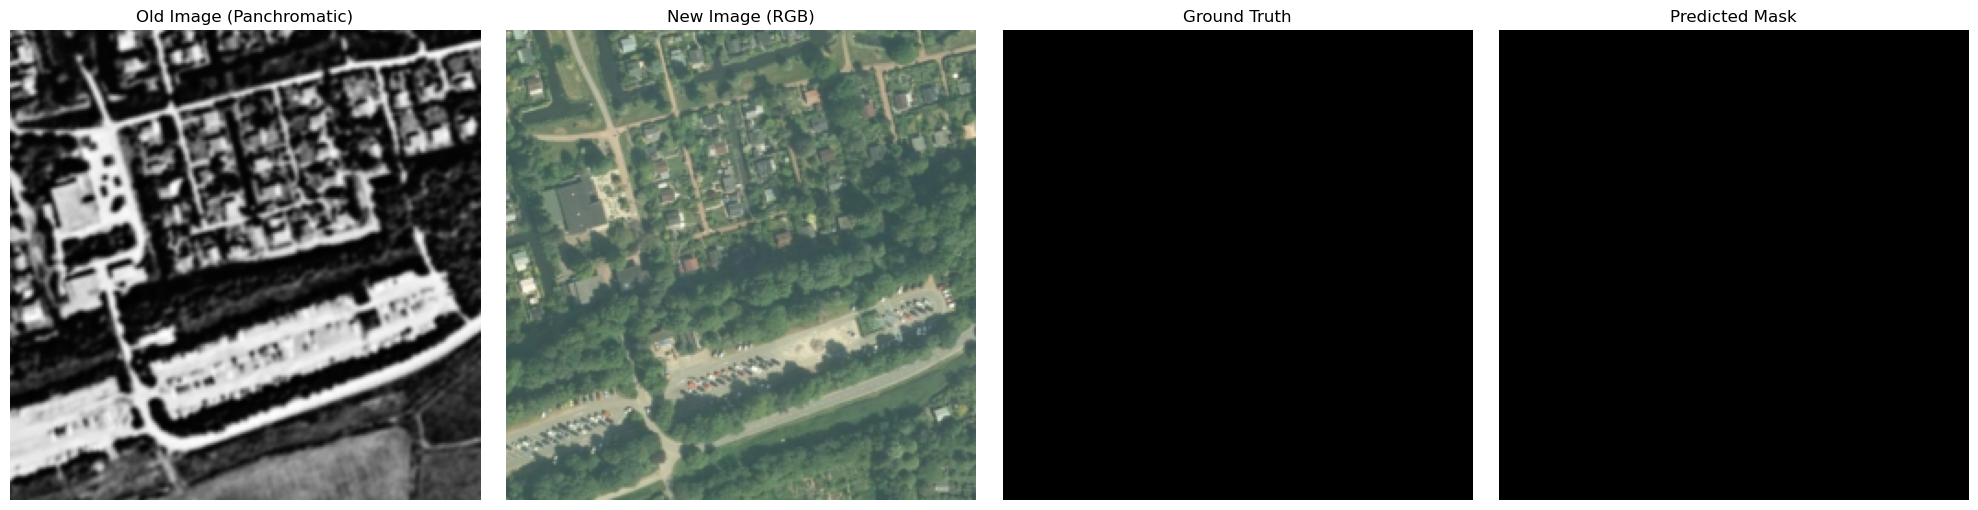

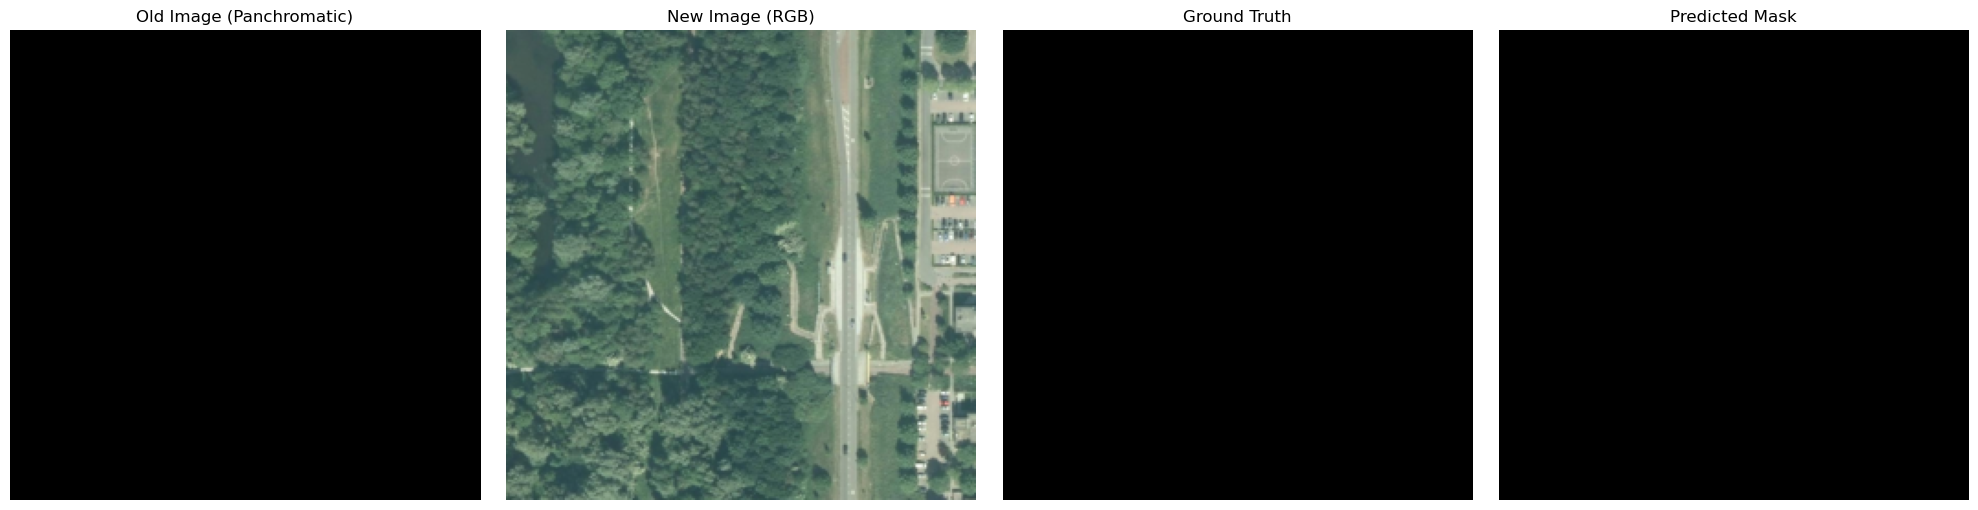

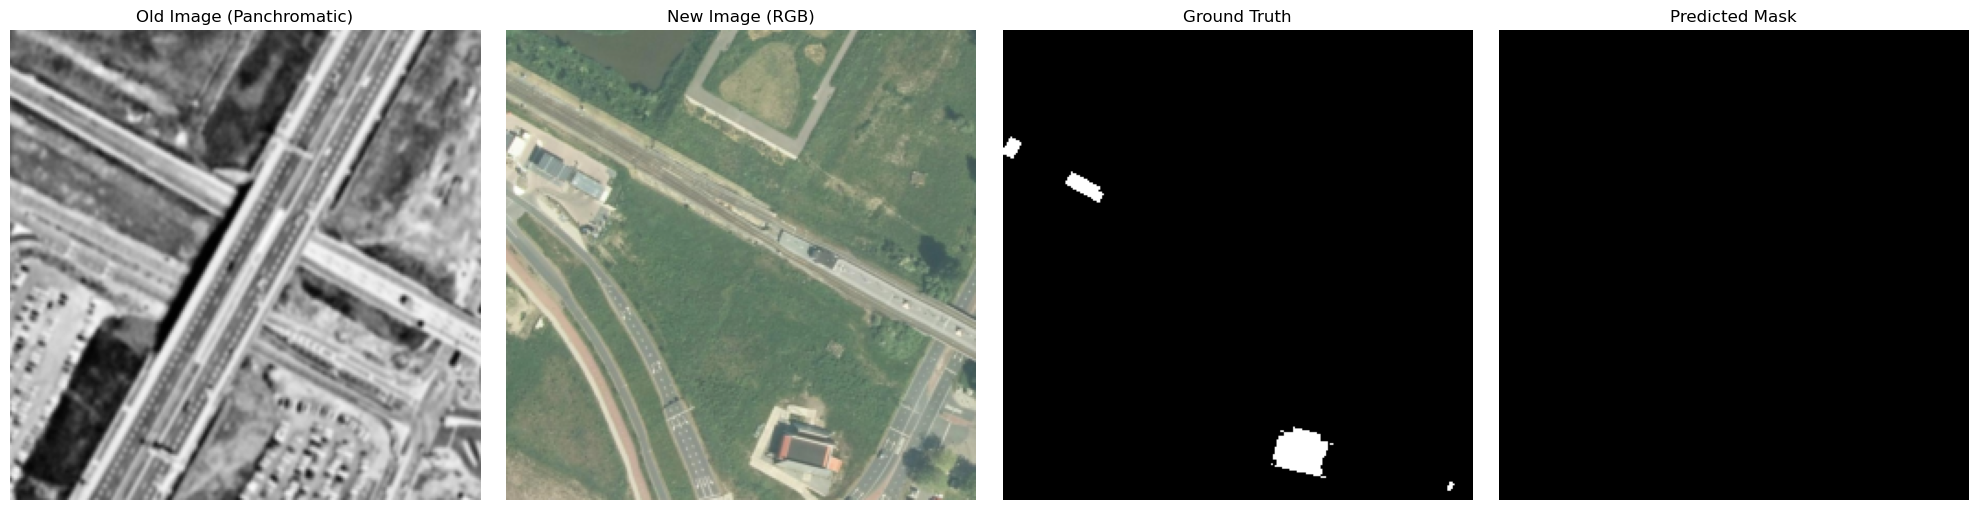

In [23]:
# Plot all samples from the batch: old image, new image, ground truth, and predicted mask
import torch
import matplotlib.pyplot as plt

dual_encoder_model.eval()
with torch.no_grad():
    x = batch_copy["image"]
    y_true = batch_copy["mask"].squeeze(1)
    logits = dual_encoder_model(x)
    y_pred = logits.argmax(dim=1)

batch_size = x.shape[0]
for i in range(batch_size):
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    # Old image (first channel)
    axs[0].imshow(x[i, 0].cpu(), cmap='gray')
    axs[0].set_title('Old Image (Panchromatic)')
    axs[0].axis('off')
    # New image (RGB)
    axs[1].imshow(torch.clamp(x[i, 1:4].permute(1, 2, 0).cpu() / 250.0, 0, 1))
    axs[1].set_title('New Image (RGB)')
    axs[1].axis('off')
    # Ground truth mask
    axs[2].imshow(y_true[i].cpu(), cmap='gray')
    axs[2].set_title('Ground Truth')
    axs[2].axis('off')
    # Predicted mask
    axs[3].imshow(y_pred[i].cpu(), cmap='gray')
    axs[3].set_title('Predicted Mask')
    axs[3].axis('off')
    plt.tight_layout()
    plt.show()

## Resampling comparison

In [ ]:
%autoreload 2
from src.datasets import KH9ImageFull, KH9ImageFullBilinear, KH9ImageFullCubic, KH9ImageFullLanczos

aoi_test_small = BoundingBox(123972.1209353197627934,124152.9746860642917454,486476.3757537123747170,486569.8168582636862993, 0, 1)

def plot(sample, title=None):
    plt.figure()
    if title is not None:
        plt.title(title)
    image = sample['image'].permute(1, 2, 0)
    image = torch.clamp(image/300, min=0, max=1).numpy()
    plt.imshow(image, cmap="gray")
    # plt.show
    # return plt

image = KH9ImageFull("/home/moritz/masterarbeit/raster/KH-9/amsterdam/georeferenced")
image_bil = KH9ImageFullBilinear("/home/moritz/masterarbeit/raster/KH-9/amsterdam/georeferenced", res=0.25)
image_cub = KH9ImageFullCubic("/home/moritz/masterarbeit/raster/KH-9/amsterdam/georeferenced", res=0.25)
image_lanc = KH9ImageFullLanczos("/home/moritz/masterarbeit/raster/KH-9/amsterdam/georeferenced", res=0.25)

plot(image[aoi_test_small], title="Original Image")
plot(image_bil[aoi_test_small], title="Bilinear Resampled Image")
plot(image_cub[aoi_test_small], title="Cubic Resampled Image")
plot(image_lanc[aoi_test_small], title="Lanczos Resampled Image")



torch.float32


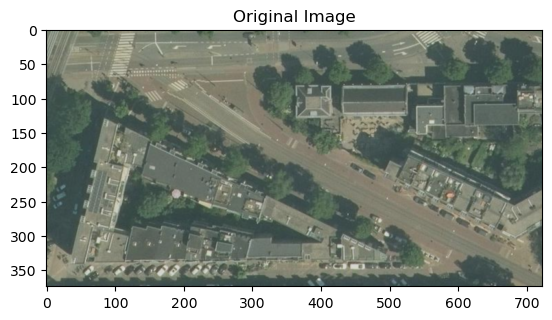

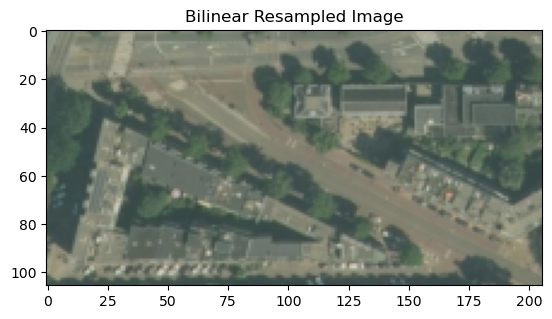

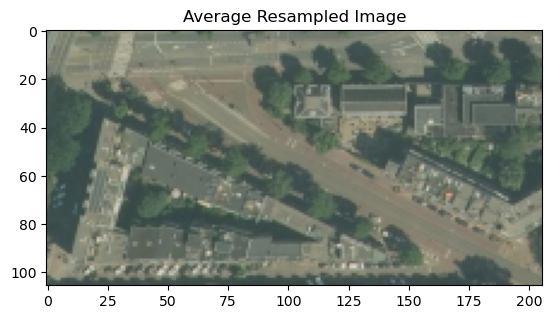

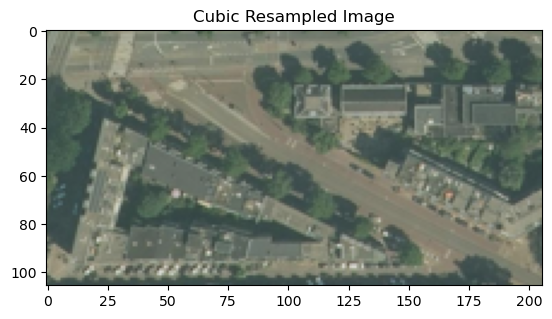

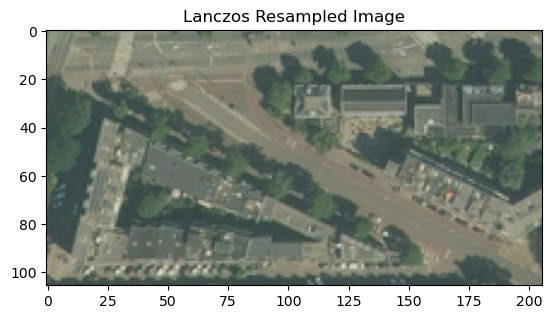

In [40]:
%autoreload 2
from src.datasets import AerialImages, AerialImagesAverage, AerialImagesCubic, AerialImagesLanczos

aoi_test_small = BoundingBox(123972.1209353197627934,124152.9746860642917454,486476.3757537123747170,486569.8168582636862993, 0, 1)

def plot(sample, title=None):
    plt.figure()
    if title is not None:
        plt.title(title)
    image = sample['image'].permute(1, 2, 0)
    image = torch.clamp(image/300, min=0, max=1).numpy()
    plt.imshow(image, cmap="gray")
    # plt.show
    # return plt

image = AerialImages("/home/moritz/masterarbeit/raster/aerial_images_2023")
image_standard = AerialImages("/home/moritz/masterarbeit/raster/aerial_images_2023", res=0.88)
image_avg = AerialImagesAverage("/home/moritz/masterarbeit/raster/aerial_images_2023", res=0.88)
image_cub = AerialImagesCubic("/home/moritz/masterarbeit/raster/aerial_images_2023", res=0.88)
image_lanc = AerialImagesLanczos("/home/moritz/masterarbeit/raster/aerial_images_2023", res=0.88)

print(image.dtype)
plot(image[aoi_test_small], title="Original Image")
plot(image_standard[aoi_test_small], title="Bilinear Resampled Image")
plot(image_avg[aoi_test_small], title="Average Resampled Image")
plot(image_cub[aoi_test_small], title="Cubic Resampled Image")
plot(image_lanc[aoi_test_small], title="Lanczos Resampled Image")

